## Introduction

As we all have heard by this point, honeybees seem to be a species on the numerical decline over the course of recent decades.

In this project, we will attempt to investigate this decline in population and how these past trends may affect the future for honeybees.

### Dataset

The dataset we will be using comes from `Kaggle.com`, and contains 8 columns or data features:

- `state`: The name of the state (abbreviated)
- `numcol`: The number of honey producing colonies
- `yieldpercol`: The yield per colony (lbs)
- `totalprod`: The total production (numcol*yieldpercol) (lbs)
- `stocks`: The Stocks held by producers on Dec 15 (lbs)
- `priceperlb`: The average price per pound ($)
- `prodvalue`: The value of production (totalprod*prodvalue) ($)
- `year`: The year that the data pertains to

## Analysis

The following sections will serve as the entirety of our study

To begin our analysis, we will start by installing and importing the necessary Python modules for this study.

In [ ]:
# Installing necessary packages
%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install scikit-learn

In [10]:
# Importing necessary modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

%matplotlib inline

Now that we have all of the necessary packages and modules installed into our virtual environment, the next thing that we need to do is load our csv file containing our dataset into a Pandas DataFrame.

In [11]:
# Loading csv into DataFrame
honey_df = pd.read_csv("honeyproduction.csv")

Next, we can display the first few rows of our data just to see how it looks in a tabular format.

In [12]:
# Displaying the first few rows of data
print(honey_df.head())

  state    numcol  yieldpercol  ...  priceperlb   prodvalue  year
0    AL   16000.0           71  ...        0.72    818000.0  1998
1    AZ   55000.0           60  ...        0.64   2112000.0  1998
2    AR   53000.0           65  ...        0.59   2033000.0  1998
3    CA  450000.0           83  ...        0.62  23157000.0  1998
4    CO   27000.0           72  ...        0.70   1361000.0  1998

[5 rows x 8 columns]


For the time being, we are really only concerned with the total honey production per year. 
Therefore, we will use the pandas `.groupby()` method to group the total honey production, `totalprod`, by year.

Then, in the same line of code, we will also assign the mean honey produced per year to variable `prod_per_year`.

In [13]:
# Getting the mean honey produced per year
prod_per_year = honey_df.groupby('year').totalprod.mean().reset_index()

# Displaying the mean honey produced per year
print(prod_per_year)

    year     totalprod
0   1998  5.105093e+06
1   1999  4.706674e+06
2   2000  5.106000e+06
3   2001  4.221545e+06
4   2002  3.892386e+06
5   2003  4.122091e+06
6   2004  4.456805e+06
7   2005  4.243146e+06
8   2006  3.761902e+06
9   2007  3.600512e+06
10  2008  3.974927e+06
11  2009  3.626700e+06
12  2010  4.382350e+06
13  2011  3.680025e+06
14  2012  3.522675e+06


Next, we will create a variable, `X`, that is the column of `year` in this `prod_per_year` DataFrame.

After creating `X`, we will need to reshape it to get it into the right format which will be displayed in the following block of code.

In [14]:
# Defining X
X = prod_per_year['year']

# Reshaping X
X = X.values.reshape(-1, 1)

Next, we will create our `y` variable which will be the `totalprod` column in our `prod_per_year` DataFrame.

In [15]:
# Defining y
y = prod_per_year['totalprod']

Now, we would like to investigate the relationship between our `X`and `y` variables.
To do this, we will plot a scatterplot of our `y` vs our `X`.

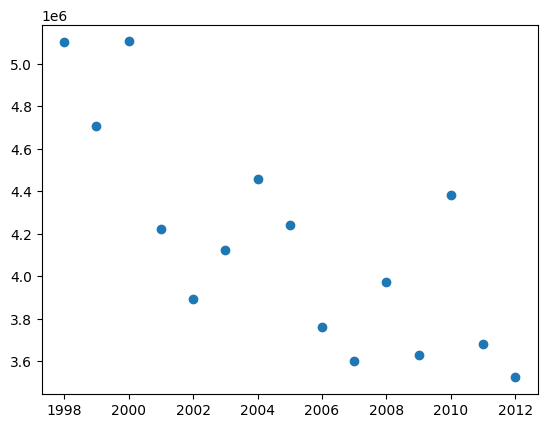

In [16]:
# Creating scatterplot
plt.scatter(X, y)

# Displaying our plot
plt.show()

In our plot above, we can see a pretty clear negative linear realtionship between the year and the total amount of honey produced.

In other words, as years go on, less honey is produced every year.

The next thing that we want to do to continue moving our study along is we want to begin to prepare our data to run a simple linear regression to get an idea of what the future of honey production looks like.

The first step in this process is defining and fitting a linear model.

In [ ]:
# Defining a linear model
regr = linear_model.LinearRegression()

# Fitting the model
regr.fit(X, y)

Now that we have our model fit to our data, we would just like to print out the slope of the line (stored in list regr.coef_) and the intercept of the line (regr.intercept_).

In [18]:
# Displaying the slope of the line
print(regr.coef_[0])

# Displaying the intercept of the line
print(regr.intercept_)

-88303.18915238192
181208083.10732976


Now we are able to get some insight on how much honey we are producing year over year!

While the actual measures are in our `prod_per_year` DataFrame, we can now see that on average, there is ~88,303 less units of honey being produced each year.

Now, we will create a list called `y_predict` that will store the predictions of honey produced that our `regr` model would make on all of our `X` data.

In [19]:
# Defining y_predict
y_predict = regr.predict(X)

Next, we want to visualize our predictions.

To do this, we will plot `y_predict` vs `X` as a line on top of our previoulsy made scatterplot using `plt.plot()`.

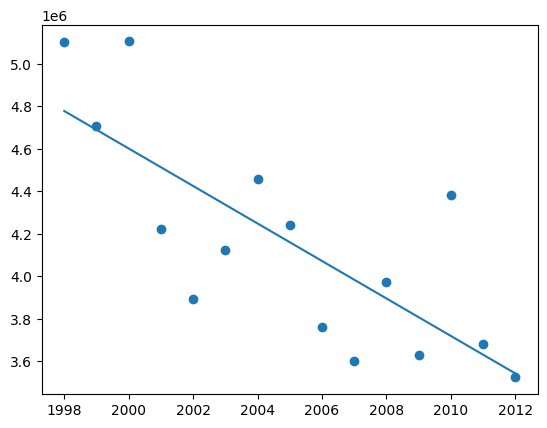

In [21]:
# Plotting trendline
plt.scatter(X, y)
plt.plot(X, y_predict)

# Displaying the new plot
plt.show()

So as we can clearly see now once again, honey production is on the decline.

But what does this mean for the future? Well, let's make some predictions to investigate.

Our known dataset stops recording data at the year `2013`, so we must first create an array that ranges from 2013 to a desired year. In this case, we will use the year `2050`.

In [22]:
# Creating out future X values
X_future = np.array(range(2013, 2051))

# Reshaping our array for sklearn
X_future = X_future.reshape(-1, 1)

Next, we will create a list to store our new predicted values in that we will call `future_predict`.

In addition to this, we will use our `regr` model to predict the total amount of honey produced up through the year 2050!

In [23]:
# Defining future_predict and running our model
future_predict = regr.predict(X_future)

Finally, let's check out our results!

To do this, we will plot `future_predict` vs `X_future` on a new plot.

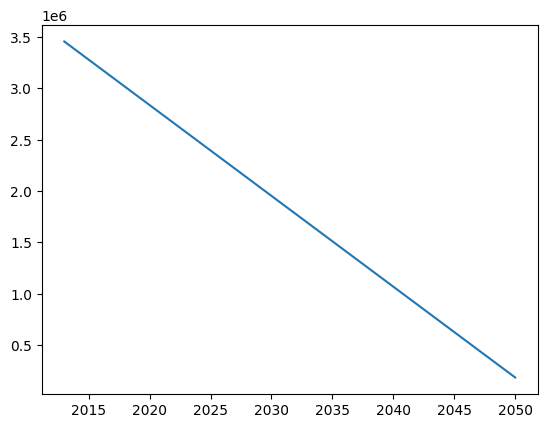

In [26]:
# Creating new plot
plt.plot(X_future, future_predict)

# Displaying our plot
plt.show()

However, this plot doesn't exactly give us all of the numbers that we are looking for.

So let's display some actual numbers to see what's going on with the total honey production for our predicting years.

In [ ]:
# Displaying data from X_predict and future_predict
print(X_future, future_predict)